# MNIST Handwritten Digit Classification

This project focuses on binary and multi-class classification using the MNIST dataset, which contains images of handwritten digits (0-9). Each image is 28x28 pixels, represented as a flattened 784-dimensional feature vector.

The project includes:
1. **Data Acquisition and Exploration**: Loading and visualizing the MNIST dataset
2. **Binary Classification**: Building a classifier to identify a single digit (digit "5")
3. **Model Comparison**: Evaluating different models for imbalanced classification
4. **Performance Analysis**: Exploring precision-recall and ROC trade-offs

In [1]:
# Import necessary libraries for data manipulation, visualization, and machine learning

# Basic libraries for data analysis and manipulation
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
import scipy.stats as stats

# Libraries for downloading and extracting data
from pathlib import Path

# Scikit-learn modules for machine learning workflows
import sklearn.datasets
import sklearn.model_selection
import sklearn.preprocessing
import sklearn.compose
import sklearn.pipeline
import sklearn.metrics
import sklearn.impute
import sklearn.base
import sklearn.multiclass

# Specific ML models
import sklearn.cluster
import sklearn.linear_model
import sklearn.tree
import sklearn.dummy
import sklearn.ensemble
import sklearn.svm

# Model saving
import joblib

# 1. Data Acquisition and Exploration

## 1.1. Data Retrieval
The MNIST dataset is fetched using scikit-learn's API, which provides convenient access to this classic machine learning benchmark dataset.

**Loading the MNIST dataset**

In [2]:
# Fetch the MNIST dataset (70,000 images of handwritten digits)
mnist = sklearn.datasets.fetch_openml('mnist_784', as_frame=False)

In [3]:
# Explore dataset structure and description
print(dir(mnist),
      mnist.DESCR,
      sep='\n')

['DESCR', 'categories', 'data', 'details', 'feature_names', 'frame', 'target', 'target_names', 'url']
**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the an

**Initial data exploration**

In [4]:
# Extract features (X) and labels (y) from the dataset
X, y = mnist.data, mnist.target

# Display sample data and dimensions
print(X[:5],
      X.shape,
      y[:5],
      y.shape,
      sep='\n\n')

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

(70000, 784)

['5' '0' '4' '1' '9']

(70000,)


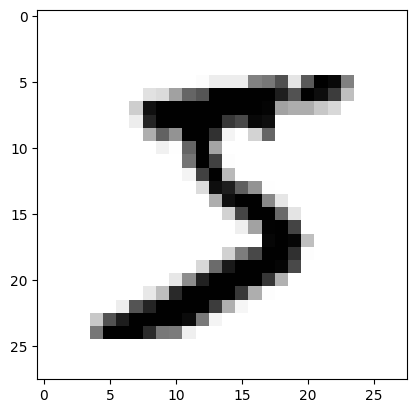

In [5]:
# Visualize the first digit image (reshape from 784-d vector to 28x28 image)
plt.imshow(X[0, :].reshape(28, 28), cmap='binary')
plt.show()

## 1.2. Train-Test Split

In [6]:
# Split the data according to MNIST convention: first 60,000 for training, last 10,000 for testing
x_train, x_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# Verify the split dimensions
print(x_train.shape,
      x_test.shape,
      y_train.shape,
      y_test.shape,
      sep='\n')

(60000, 784)
(10000, 784)
(60000,)
(10000,)


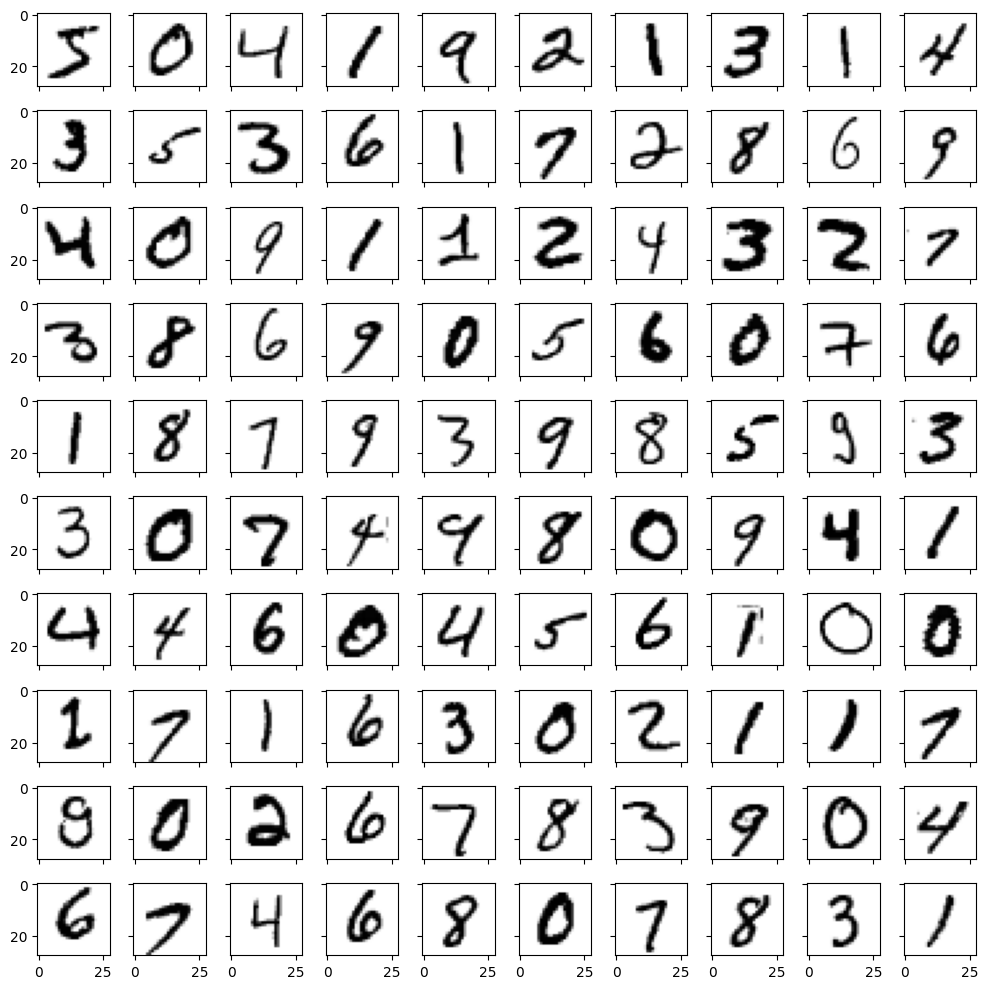

In [7]:
# Visualize a grid of sample images from the training set
nrows = 10
ncolumns = 10
fig, ax = plt.subplots(nrows=nrows, ncols=ncolumns, figsize=(ncolumns, nrows), sharex=True, sharey=True)

for i in range(0, nrows * ncolumns):
    # Display each image in its corresponding subplot
    axs = ax[i // nrows, i % ncolumns]
    axs.imshow(x_train[i,:].reshape(28, 28), cmap='binary')

plt.tight_layout()
plt.show()

**Note on preprocessing**: The MNIST data is already preprocessed (centered and normalized pixel values). Since each feature represents a pixel intensity in a 28x28 image, traditional statistical exploration of feature distributions is not necessary. The focus will be directly on model training and evaluation.

# 2. Binary Classification: Digit "5" Detection

This section focuses on building a binary classifier to detect whether an image represents the digit "5" or not. This transforms the multi-class problem into a binary classification task, which is useful for understanding model behavior with imbalanced datasets.

## 2.1. Creating Binary Labels and Analyzing Class Imbalance

In [8]:
# Convert multi-class labels to binary: True if digit is "5", False otherwise
y_train_5 = (y_train.copy() == '5')
y_test_5 = (y_test.copy() == '5')

# Examine class distribution to identify imbalance
print(pd.Series(y_train_5).value_counts(),
      pd.Series(y_test_5).value_counts(),
      sep='\n')

False    54579
True      5421
Name: count, dtype: int64
False    9108
True      892
Name: count, dtype: int64


## 2.2. Baseline Model: Stochastic Gradient Descent Classifier

In [9]:
# Train an SGD classifier (uses linear SVM by default)
sgd_model = sklearn.linear_model.SGDClassifier(random_state=42)
sgd_model = sgd_model.fit(x_train, y_train_5)

# Evaluate accuracy on training set
sklearn.metrics.accuracy_score(y_train_5, sgd_model.predict(x_train))

0.9522666666666667

In [10]:
# Assess generalization performance using 3-fold cross-validation
cv_sgd = sklearn.model_selection.cross_val_score(estimator=sgd_model, X=x_train, y=y_train_5, cv=3, scoring='accuracy')
pd.Series(cv_sgd).describe()

count    3.000000
mean     0.957033
std      0.005788
min      0.950350
25%      0.955350
50%      0.960350
75%      0.960375
max      0.960400
dtype: float64

The model shows high accuracy, but this may be misleading due to class imbalance (most digits are not "5"). To verify whether the model is truly learning patterns or simply exploiting the imbalance, we'll compare it against a naive baseline.

## 2.3. Baseline Comparison: Dummy Classifier

To understand if the SGD model is truly effective, we compare it against a dummy classifier that always predicts the most frequent class. This helps identify whether high accuracy is genuine or merely a result of class imbalance.

In [11]:
# Train a dummy classifier that always predicts the most frequent class
dummy_model = sklearn.dummy.DummyClassifier(strategy='most_frequent')
dummy_model = dummy_model.fit(x_train, y_train_5)

# Evaluate accuracy on training set
sklearn.metrics.accuracy_score(y_train_5, dummy_model.predict(x_train))

0.90965

In [12]:
# Evaluate dummy classifier using cross-validation
cv_dummy = sklearn.model_selection.cross_val_score(estimator=dummy_model, X=x_train, y=y_train_5, cv = 3, scoring='accuracy')
pd.Series(cv_dummy).describe()

count    3.00000
mean     0.90965
std      0.00000
min      0.90965
25%      0.90965
50%      0.90965
75%      0.90965
max      0.90965
dtype: float64

The dummy classifier achieves comparable accuracy to the SGD model, confirming that the dataset has significant class imbalance. This reveals that accuracy alone is an inadequate metric for evaluating performance in imbalanced classification tasks. We need to examine additional metrics like precision, recall, and confusion matrices to properly assess model quality.

## 2.4. Performance Analysis Beyond Accuracy

This section explores comprehensive evaluation metrics and trade-offs for the SGD classifier, focusing on metrics more appropriate for imbalanced datasets.

### Confusion Matrix Analysis

In [13]:
# Generate confusion matrix to understand prediction patterns
class_labels = sgd_model.classes_

cmatrix = sklearn.metrics.confusion_matrix(y_train_5, sgd_model.predict(x_train))
pd.DataFrame(cmatrix, index=class_labels, columns=class_labels)
# The confusion matrix reveals class imbalance and helps identify false positives/negatives

,False,True
False,52316,2263
True,601,4820


In [14]:
# Compute comprehensive performance metrics
print(f'Accuracy: {sklearn.metrics.accuracy_score(y_train_5, sgd_model.predict(x_train))}',
      f'Precision: {sklearn.metrics.precision_score(y_train_5, sgd_model.predict(x_train))}',
      f'Recall: {sklearn.metrics.recall_score(y_train_5, sgd_model.predict(x_train))}',
      f'Specificity: {cmatrix[1, 1] / sum(cmatrix[1, :])}',
      f'False positive discovery score: {cmatrix[1, 0] / sum(cmatrix[1, :])}',
      sep='\n')

Accuracy: 0.9522666666666667
Precision: 0.6805026118876183
Recall: 0.8891348459693783
Specificity: 0.8891348459693783
False positive discovery score: 0.11086515403062165


The metrics reveal that while the model has high accuracy and recall, it suffers from lower precision. This indicates difficulty in correctly predicting the minority class (digit "5"), with the model generating false positives.

### Precision-Recall Trade-off Analysis

By exploring the precision-recall trade-off, we can investigate threshold tuning to improve model balance. Adjusting the decision threshold allows us to prioritize either precision or recall based on the application requirements.

In [15]:
# Compute precision and recall values across different decision thresholds
precision, recall, thresholds = sklearn.metrics.precision_recall_curve(y_true=y_train_5, y_score=sgd_model.decision_function(x_train))

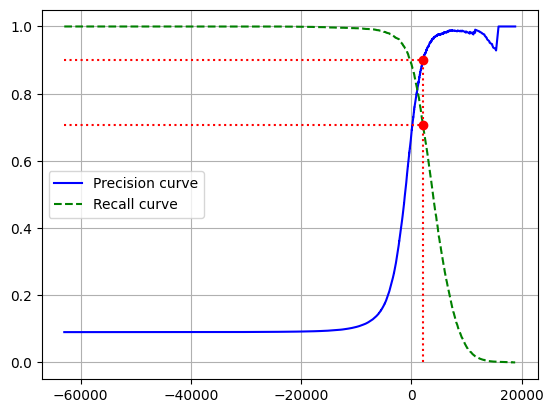

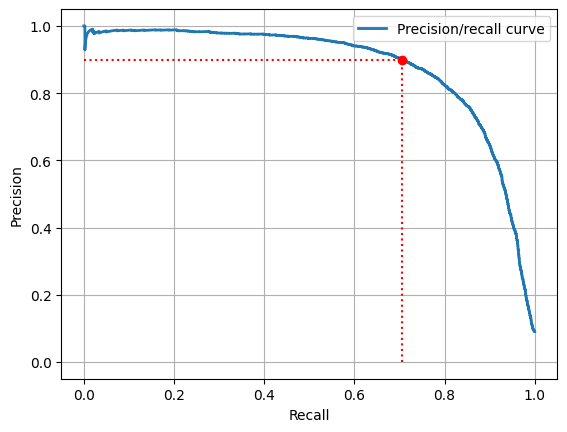

Threshold for 90% precision: 2123.5620469950154


In [16]:
# Find the threshold that achieves 90% precision
recall_90_precision = recall[np.argmax(precision >= 0.90)]
threshold_90_precision = thresholds[np.argmax(precision >= 0.90)]

# Visualize how precision and recall vary with threshold
plt.plot(thresholds, precision[:-1], 'b-', label= 'Precision curve')
plt.plot(thresholds, recall[:-1], 'g--', label = 'Recall curve')
plt.plot([threshold_90_precision, threshold_90_precision], [0., 0.9], "r:")
plt.plot([np.min(thresholds), threshold_90_precision], [0.9, 0.9], "r:")
plt.plot([np.min(thresholds), threshold_90_precision], [recall_90_precision, recall_90_precision], "r:")
plt.plot([threshold_90_precision], [0.9], "ro")
plt.plot([threshold_90_precision], [recall_90_precision], "ro")
plt.grid()
plt.legend()
plt.show()

# Visualize the precision-recall trade-off curve
plt.plot(recall, precision, linewidth=2, label='Precision/recall curve')
plt.plot([recall_90_precision, recall_90_precision], [0., 0.9], "r:")
plt.plot([0.0, recall_90_precision], [0.9, 0.9], "r:")
plt.plot([recall_90_precision], [0.9], "ro")
plt.grid()
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

# Display the threshold needed for 90% precision
print('Threshold for 90% precision: {}'.format(threshold_90_precision))

The plots demonstrate that threshold optimization could balance precision and recall to achieve approximately 80% for both metrics. However, in practice, we typically prioritize one metric over the other based on application needs (e.g., minimizing false positives vs. catching all true positives).

### ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve provides another perspective on model performance by illustrating the trade-off between recall (true positive rate) and the false positive rate across different thresholds.

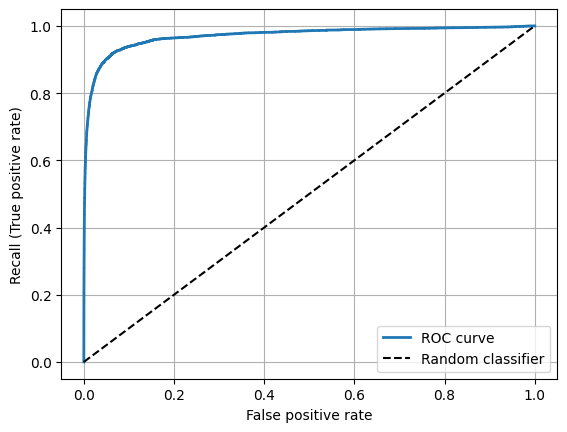

0.9709618248430906

In [17]:
# Compute and visualize the ROC curve
fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_train_5, sgd_model.decision_function(x_train))
plt.plot(fpr, tpr, linewidth=2, label='ROC curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False positive rate')
plt.ylabel('Recall (True positive rate)')
plt.grid()
plt.legend()
plt.show()

# Calculate the Area Under the ROC Curve (AUC) as a single-number performance metric
sklearn.metrics.roc_auc_score(y_train_5, sgd_model.decision_function(x_train))

The ROC curve reveals two key insights:

1. **Threshold Trade-off**: Modifying the decision threshold can improve recall, but at the cost of increasing the false positive rate (reducing specificity). This highlights the need to carefully balance these metrics based on application requirements.

2. **Model Improvement Potential**: While the curve shows the SGD model performs reasonably well, the area above the curve suggests there may be better modeling approaches worth exploring.

## 2.5. Alternative Model: Random Forest Classifier

Based on the ROC analysis suggesting potential for improvement, we'll evaluate a Random Forest classifier as an alternative approach. Random Forests can capture non-linear patterns and complex interactions that linear models may miss.

In [18]:
# Train a Random Forest classifier with default parameters
rf_model = sklearn.ensemble.RandomForestClassifier(random_state=42)
rf_model = rf_model.fit(x_train, y_train_5)

# Evaluate initial accuracy
sklearn.metrics.accuracy_score(y_train_5, rf_model.predict(x_train))

1.0

In [19]:
# Examine the confusion matrix
sklearn.metrics.confusion_matrix(y_train_5, rf_model.predict(x_train))

array([[54579,     0],
       [    0,  5421]])

In [20]:
# Assess generalization via cross-validation
rf_results = sklearn.model_selection.cross_val_score(estimator=rf_model, X=x_train, y=y_train_5, cv=3, scoring='accuracy')
pd.Series(rf_results).describe()

count    3.000000
mean     0.987167
std      0.001458
min      0.986300
25%      0.986325
50%      0.986350
75%      0.987600
max      0.988850
dtype: float64

In [21]:
# Generate cross-validated probability predictions for threshold analysis
rf_predictions = sklearn.model_selection.cross_val_predict(rf_model, x_train, y_train_5, cv=3, method='predict_proba')
rf_predictions[:5]

array([[0.11, 0.89],
       [0.99, 0.01],
       [0.96, 0.04],
       [1.  , 0.  ],
       [0.99, 0.01]])

### Random Forest Performance Curves

In [22]:
# Compute precision-recall curve using cross-validated predictions
precision, recall, thresholds = sklearn.metrics.precision_recall_curve(y_train_5, rf_predictions[:, 1])

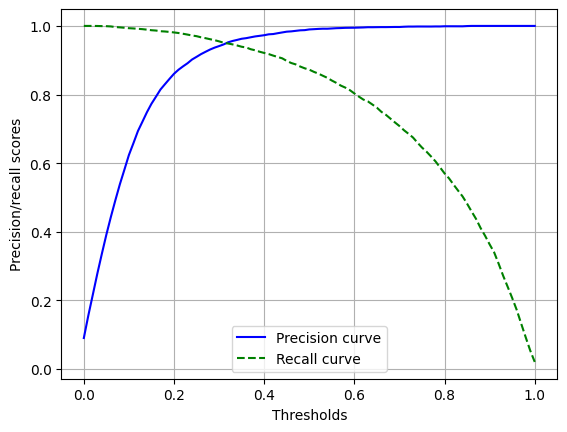

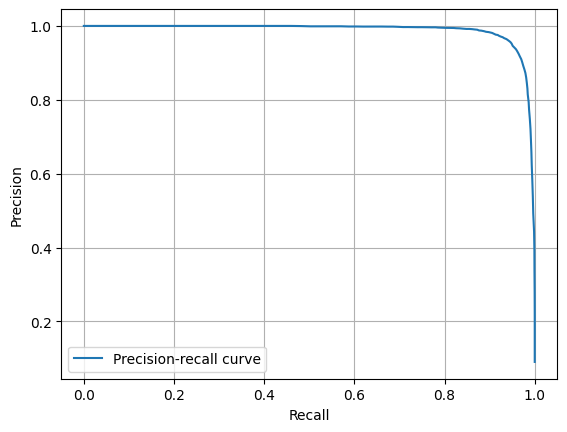

In [23]:
# Visualize the precision-recall trade-off for Random Forest

# Plot how precision and recall change with threshold
plt.plot(thresholds, precision[:-1], 'b-', label='Precision curve')
plt.plot(thresholds, recall[:-1], 'g--', label='Recall curve')
plt.legend()
plt.xlabel('Thresholds')
plt.ylabel('Precision/recall scores')
plt.grid()
plt.show()

# Plot the direct precision-recall trade-off
plt.plot(recall, precision, label = 'Precision-recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid()
plt.show()

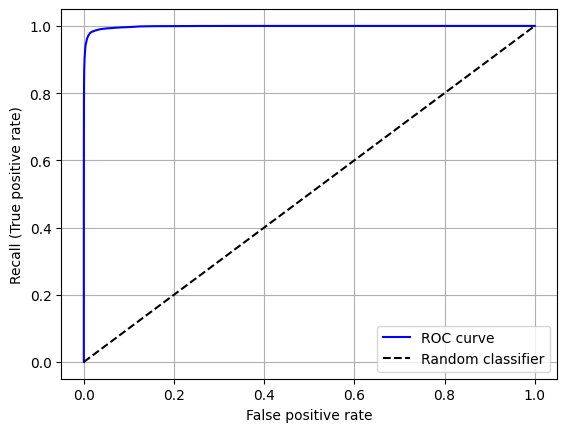

0.9983436731328145

In [24]:
# Compute and visualize the ROC curve for Random Forest
fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_train_5, rf_predictions[:, 1])

plt.plot(fpr, tpr, 'b-', label = 'ROC curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False positive rate')
plt.ylabel('Recall (True positive rate)')
plt.grid()
plt.legend()
plt.show()

# Calculate AUC score as a summary metric
sklearn.metrics.roc_auc_score(y_true=y_train_5, y_score=rf_predictions[:, 1])

### Model Comparison Summary

The Random Forest classifier demonstrates substantially better performance compared to the SGD linear classifier across all evaluation metrics:
- Higher accuracy
- Better precision-recall balance
- Superior ROC curve with higher AUC score

This comprehensive improvement confirms that the Random Forest is better suited for this binary classification task, successfully capturing the non-linear patterns in the handwritten digit images.

# 3. Multilabel classification

This section focuses on building a multilabel classifier to detect the digits writen in the different images.

In [25]:
# Training a supported vector machine classifier for a multiclass problem
svm_model = sklearn.svm.SVC()
svm_model = svm_model.fit(x_train, y_train)

# Estimating the performance via accuracy
sklearn.metrics.accuracy_score(y_train[0:10], svm_model.predict(x_train[0:10]))

1.0

As the supported vector calssifier algorithm has been designed for two classes. By default, the strategy adopted by the algorithm is a OvO (one versus one). Which computes a model for every two-pairs of elements.

Therefore, because of this, we have that the model is computational expensive with, on average, a run of 21 minutes and estimation of 45 models.

In [28]:
# Evidencing the output for a particular observation
predict_proba = svm_model.decision_function(x_train[[10],:])
print(predict_proba)

# Determining which is the most likely class based on the score:
print(svm_model.classes_[np.argmax(predict_proba)])

[[ 2.73719174  6.20651629  3.81372559  9.32009109  0.69223349  6.26207869
  -0.31019599  1.69984884  8.29382546  6.23989726]]
3


In order to compare its performance against a OvR (one versus rest), we would set it up in this fashion.

In [32]:
# Training a supported vector machine classifier for a multiclass problem
svm_class = sklearn.multiclass.OneVsRestClassifier(estimator=svm_model)
svm_class = svm_class.fit(x_train, y_train)

# Estimating the performance via accuracy
sklearn.metrics.accuracy_score(y_train[0:10], svm_class.predict(x_train[0:10]))

1.0

In [ ]:
# Evaluating via cross-validation
svm_results = sklearn.model_selection.cross_val_score(svm_class, x_train, y_train, cv = 3, scoring='accuracy')
pd.Series(svm_results).describe()